In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [116]:
df = pd.read_csv(r"./airline_passengers.csv")
df.drop(index=144,axis=0,inplace=True)
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.set_index('Month',inplace=True)
df.sort_index()
df.head()

,Thousands of Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


<Axes: xlabel='Month'>

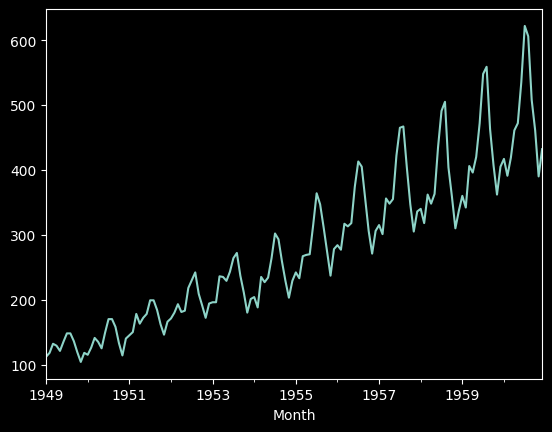

In [117]:
df['Thousands of Passengers'].plot()

<Axes: xlabel='Month'>

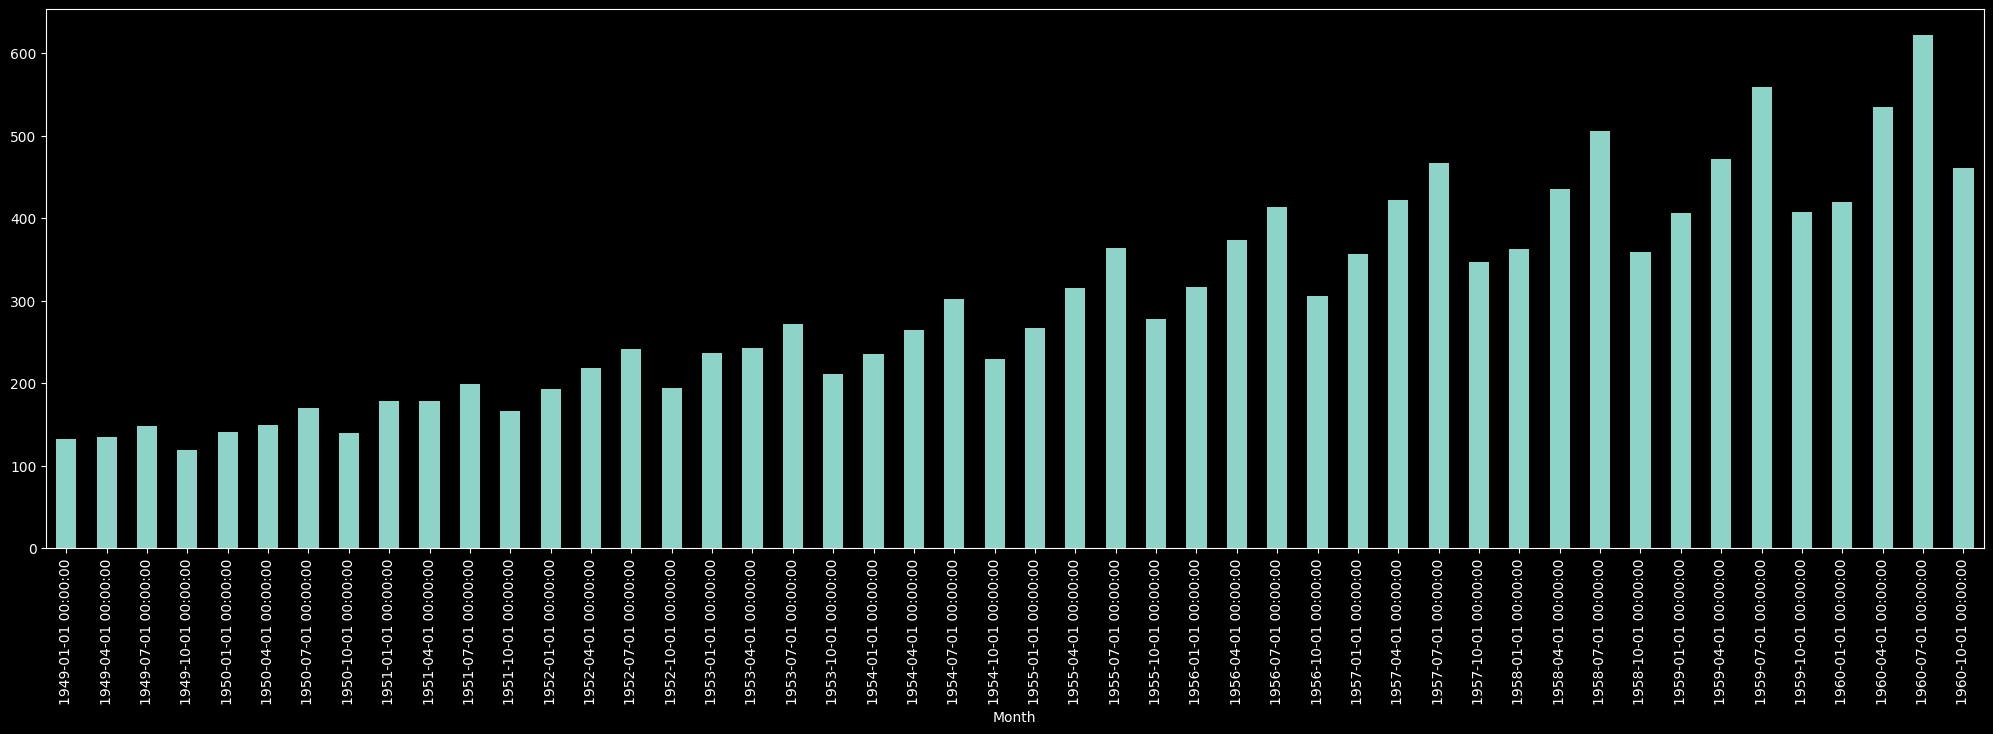

In [118]:
df.resample(rule='QS').max()['Thousands of Passengers'].plot(kind='bar',figsize=(25,7))

<Axes: xlabel='Month'>

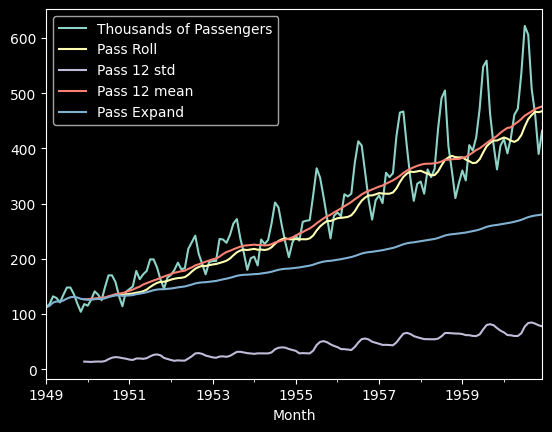

In [119]:
df['Pass Roll'] = df['Thousands of Passengers'].rolling(window=20).mean()
df['Thousands of Passengers'].plot(legend=True)
df['Pass Roll'].plot(legend=True)
df['Pass 12 std']=df['Thousands of Passengers'].rolling(window=12).std()
df['Pass 12 mean']=df['Thousands of Passengers'].rolling(window=12).mean()
df['Pass 12 std'].plot(legend=True)
df['Pass 12 mean'].plot(legend=True)
df['Pass Expand']= df['Thousands of Passengers'].expanding().mean()
df['Pass Expand'].plot(legend=True)

<Axes: xlabel='Month'>

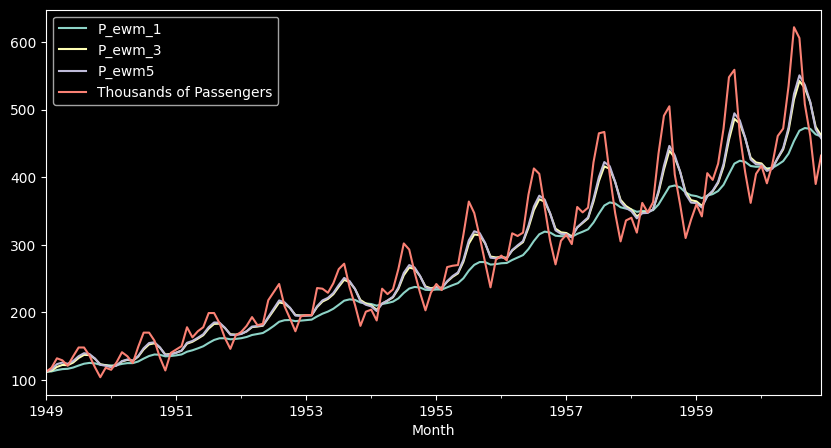

In [120]:
df['P_ewm_1'] = df['Thousands of Passengers'].ewm(alpha=0.1, adjust=False).mean()
df['P_ewm_3'] = df['Thousands of Passengers'].ewm(alpha=0.3, adjust=False).mean()
df['P_ewm5'] = df['Thousands of Passengers'].ewm(span=5).mean()
df[['P_ewm_1','P_ewm_3','P_ewm5','Thousands of Passengers']].plot(figsize=(10,5))

In [121]:
from statsmodels.tsa.stattools import adfuller
def adf_test(data):
    result = adfuller(data)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:", result[4])
    if result[1] < 0.05:
        print("Reject the null hypothesis: The series is stationary.")
    else:
        print("Fail to reject the null hypothesis: The series is non-stationary.")


In [122]:
adf_test(df['Thousands of Passengers'])

ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
Fail to reject the null hypothesis: The series is non-stationary.


In [123]:
df['TP_Diff_1'] = df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(1)
adf_test(df['TP_Diff_1'].dropna())

ADF Statistic: -2.8292668241699923
p-value: 0.054213290283826474
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
Fail to reject the null hypothesis: The series is non-stationary.


In [124]:
df['TP_Diff_2'] = df['TP_Diff_1'] - df['TP_Diff_1'].shift(1)
adf_test(df['TP_Diff_2'].dropna())

ADF Statistic: -16.384231542468516
p-value: 2.7328918500141235e-29
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
Reject the null hypothesis: The series is stationary.


In [125]:
df['TP_Diff_12'] = df['Thousands of Passengers'] - df['Thousands of Passengers'].shift(12)
adf_test(df['TP_Diff_12'].dropna())

ADF Statistic: -3.383020726492481
p-value: 0.011551493085514954
Critical Values: {'1%': -3.4816817173418295, '5%': -2.8840418343195267, '10%': -2.578770059171598}
Reject the null hypothesis: The series is stationary.


In [126]:

from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

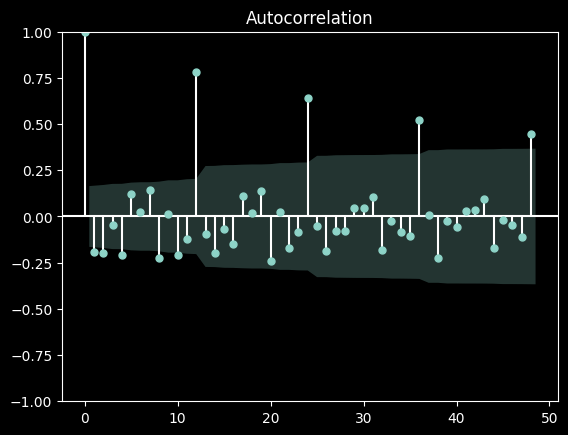

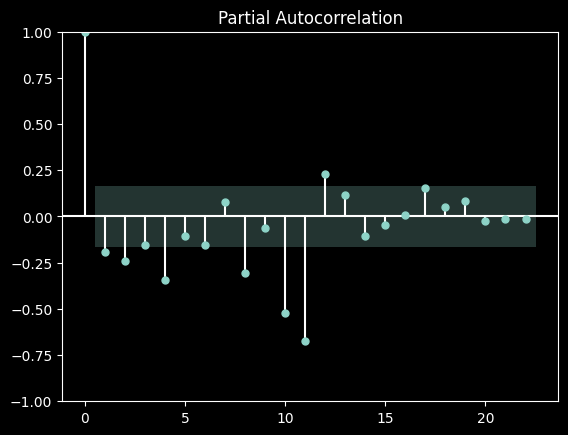

In [127]:
acf = plot_acf(df['TP_Diff_2'].dropna(),lags=48)
pacf = plot_pacf(df['TP_Diff_2'].dropna())

In [128]:
from datetime import  datetime, timedelta
train = datetime(1955,12,1)
test = datetime(1960,12,1)

In [129]:
train_df = df[:train].copy()
test_df = df[train+timedelta(days=1):test].copy()
pred_start = test_df.index[0]
pred_end = test_df.index[-1]

In [130]:
from statsmodels.tsa.arima.model import ARIMA
model_ARIMA=ARIMA(train_df['Thousands of Passengers'],order=(3,2,4),freq='MS')
model_Arima_fit=model_ARIMA.fit()
model_Arima_fit.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     Thousands of Passengers   No. Observations:                   84
Model:                      ARIMA(3, 2, 4)   Log Likelihood                -360.478
Date:                     Sat, 07 Dec 2024   AIC                            736.955
Time:                             23:30:04   BIC                            756.209
Sample:                         01-01-1949   HQIC                           744.685
                              - 12-01-1955                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0887      0.108    -10.103      0.000      -1.300      -0.877
ar.L2         -0.9274      0.146     -6.365      0.000      -1.213      -0.642
ar.L3         -0.5187      0.116     -4.483      0.000      -0.745      -0.292
ma.L1          0.4445    105.392      0.004      0.997    -206.120     207.009
ma.L2         -0.0016     46.428  -3.51e-05      1.000     -90.999      90.996
ma.L3         -0.4445    105.177     -0.004      0.997    -206.588     205.699
ma.L4         -0.9984      0.196     -5.092      0.000      -1.383      -0.614
sigma2       339.2980      0.955    355.203      0.000     337.426     341.170
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 0.69
Prob(Q):                              0.90   Prob(JB):                         0.71
Heteroskedasticity (H):               3.40   Skew:                             0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 9.37e+20. Standard errors may be unstable.
"""

<Axes: xlabel='Month'>

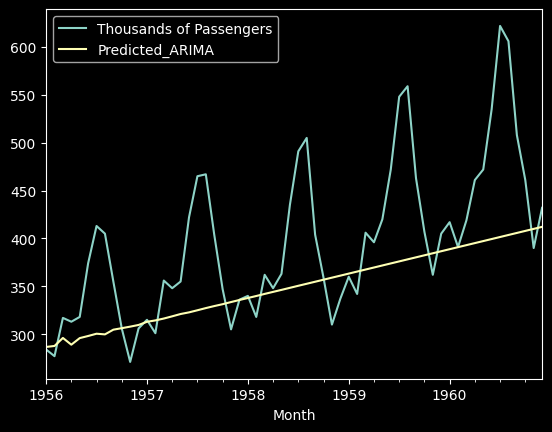

In [131]:
pred=model_Arima_fit.predict(start=pred_start,end=pred_end)
test_df['Predicted_ARIMA']=pred
test_df[['Thousands of Passengers','Predicted_ARIMA']].plot()

<Axes: ylabel='Density'>

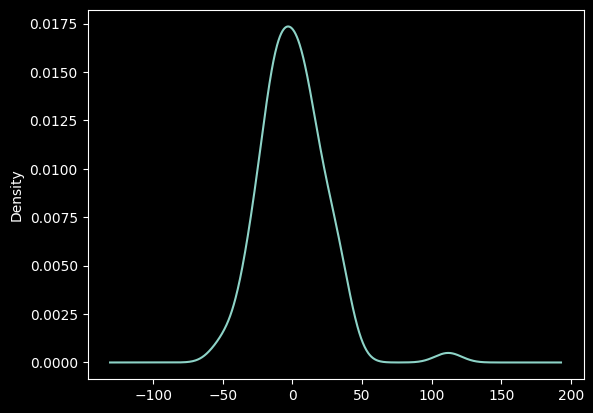

In [132]:
model_Arima_fit.resid.plot(kind='kde')


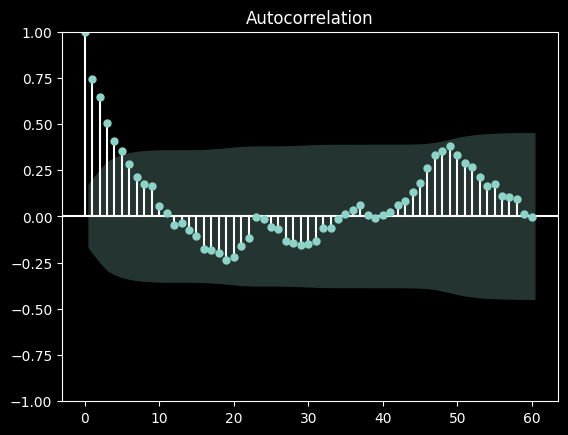

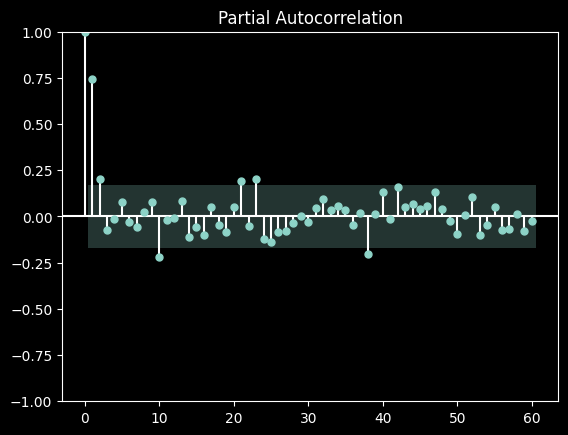

In [133]:
acf12 = plot_acf(df['TP_Diff_12'].dropna(),lags=60)
pacf12 = plot_pacf(df['TP_Diff_12'].dropna(),lags=60)

In [134]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_SARIMA=SARIMAX(train_df['Thousands of Passengers'],order=(3,0,5),seasonal_order=(3,1,5,12),freq='MS')
model_SARIMA_fit=model_SARIMA.fit()
model_SARIMA_fit.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:            Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(3, 1, 5, 12)   Log Likelihood                -261.904
Date:                            Sat, 07 Dec 2024   AIC                            557.808
Time:                                    23:30:13   BIC                            596.512
Sample:                                01-01-1949   HQIC                           573.216
                                     - 12-01-1955                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1009      1.644      0.670      0.503      -2.121       4.323
ar.L2         -0.4615      2.631     -0.175      0.861      -5.618       4.695
ar.L3          0.3347      2.013      0.166      0.868      -3.610       4.280
ma.L1         -0.3832      1.620     -0.237      0.813      -3.559       2.792
ma.L2          0.4368      2.105      0.207      0.836      -3.689       4.563
ma.L3         -0.2744      0.576     -0.476      0.634      -1.404       0.855
ma.L4          0.0110      0.476      0.023      0.982      -0.922       0.944
ma.L5          0.0276      0.471      0.059      0.953      -0.895       0.950
ar.S.L12      -0.4641   1318.347     -0.000      1.000   -2584.377    2583.449
ar.S.L24       0.3278   1486.367      0.000      1.000   -2912.898    2913.554
ar.S.L36       0.6223   3159.706      0.000      1.000   -6192.288    6193.533
ma.S.L12       0.2962   4874.528   6.08e-05      1.000   -9553.604    9554.196
ma.S.L24      -0.5695   4.34e+04  -1.31e-05      1.000   -8.51e+04    8.51e+04
ma.S.L36      -0.5889   4.73e+04  -1.24e-05      1.000   -9.28e+04    9.28e+04
ma.S.L48       0.2487   8647.849   2.88e-05      1.000   -1.69e+04    1.69e+04
ma.S.L60       0.9157    886.382      0.001      0.999   -1736.360    1738.192
sigma2        39.8147   6.46e+04      0.001      1.000   -1.27e+05    1.27e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                 3.12
Prob(Q):                              0.82   Prob(JB):                         0.21
Heteroskedasticity (H):               2.54   Skew:                             0.51
Prob(H) (two-sided):                  0.03   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Month'>

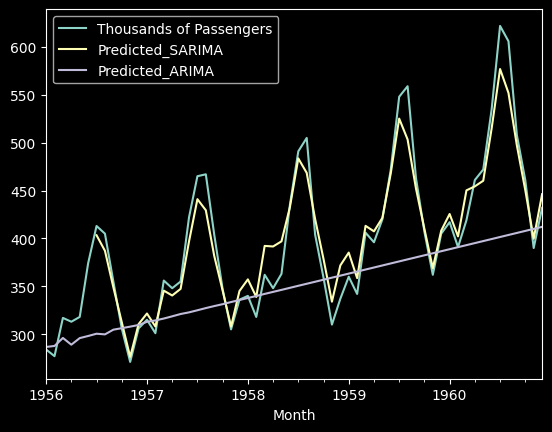

In [135]:
pred_Sarima=model_SARIMA_fit.predict(start=datetime(1956,6,6),end=datetime(1960,12,1))
test_df['Predicted_SARIMA']=pred_Sarima
test_df[['Thousands of Passengers','Predicted_SARIMA','Predicted_ARIMA']].plot()

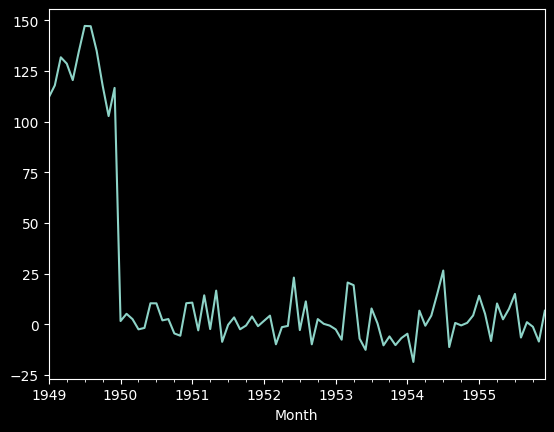

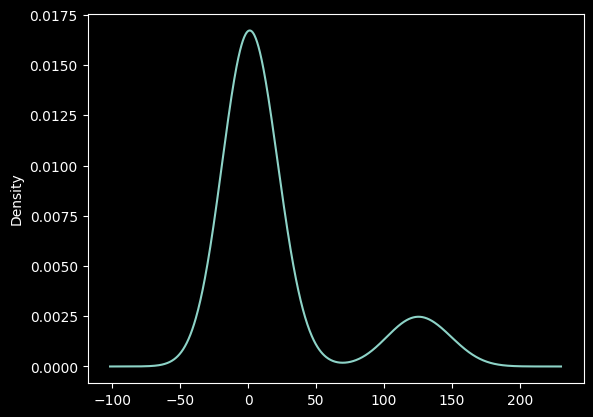

In [136]:
model_SARIMA_fit.resid.plot()
plt.show()
model_SARIMA_fit.resid.plot(kind='kde')
plt.show()

In [137]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error, root_mean_squared_error
print("R2 score: ",r2_score(test_df.dropna()['Predicted_SARIMA'],test_df.dropna()['Thousands of Passengers']))
print("100-MAPE score: ",100-mean_absolute_percentage_error(test_df.dropna()['Predicted_SARIMA'],test_df.dropna()['Thousands of Passengers']))
print("RMSE score: ",root_mean_squared_error(test_df.dropna()['Predicted_SARIMA'],test_df.dropna()['Thousands of Passengers']))

R2 score:  0.8911887474607664
100-MAPE score:  99.96007803294063
RMSE score:  21.3951986858117


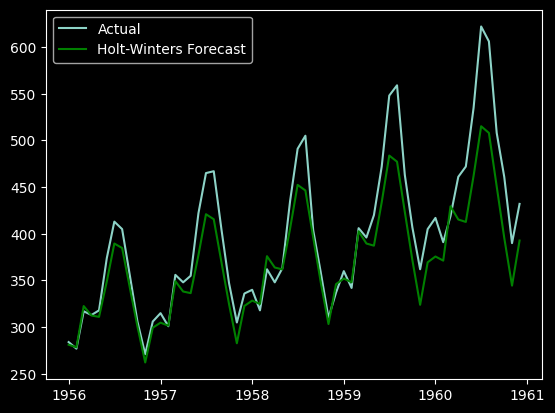

In [138]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Fit Holt-Winters model
holt_winters_model = ExponentialSmoothing(train_df['Thousands of Passengers'], trend="add", seasonal="multiplicative", seasonal_periods=12,freq='MS')
holt_winters_fit = holt_winters_model.fit()

# Forecast
holt_winters_forecast = holt_winters_fit.forecast(steps=len(test_df))
test_df['Holt'] = holt_winters_forecast
# Plot Results
plt.plot(test_df['Thousands of Passengers'], label="Actual")
plt.plot(holt_winters_forecast, label="Holt-Winters Forecast", color="green")
plt.legend()
plt.show()


In [139]:
print("R2 score: ",r2_score(test_df.dropna()['Holt'],test_df.dropna()['Thousands of Passengers']))
print("100-MAPE score: ",100-mean_absolute_percentage_error(test_df.dropna()['Holt'],test_df.dropna()['Thousands of Passengers']))
print("RMSE score: ",root_mean_squared_error(test_df.dropna()['Holt'],test_df.dropna()['Thousands of Passengers']))

R2 score:  0.5234870685056757
100-MAPE score:  99.92613314917716
RMSE score:  38.94458576824612


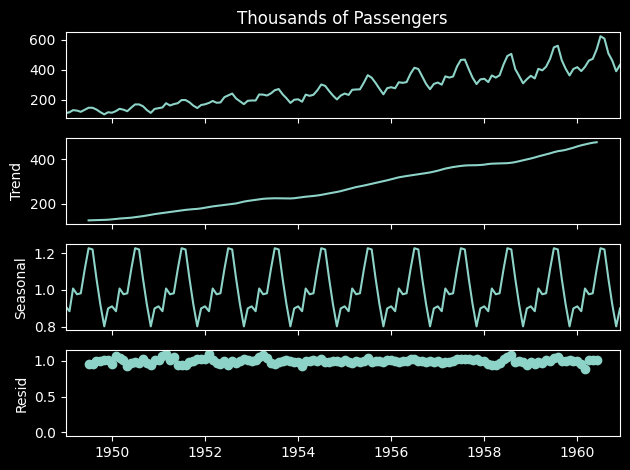

Seasonal Factors:
 Month
1949-03-01    1.007366
1949-04-01    0.975906
1949-05-01    0.981378
1949-06-01    1.112776
1949-07-01    1.226556
1949-08-01    1.219911
1949-09-01    1.060492
1949-10-01    0.921757
1949-11-01    0.801178
1949-12-01    0.898824
1950-01-01    0.910230
1950-02-01    0.883625
Name: seasonal, dtype: float64


In [140]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Thousands of Passengers'], model="multiplicative", period=12)
trend = result.trend
seasonal = result.seasonal
residual = result.resid
result.plot()
plt.show()
seasonal_factors = seasonal[2:14] 
print("Seasonal Factors:\n", seasonal_factors)

2.0
Drift: 2.1429280145793266


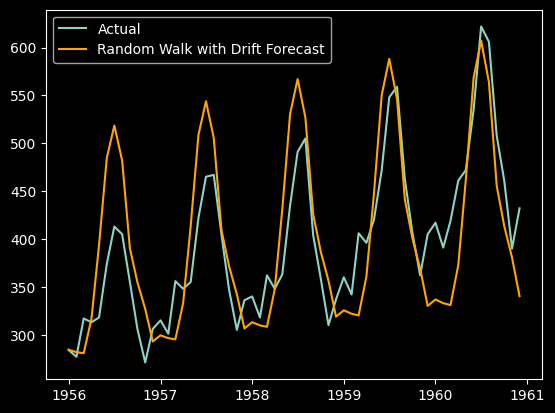

In [141]:
seasonal_factors = seasonal_factors / seasonal_factors.mean()
train = train_df['Thousands of Passengers'].copy()
drift = train.diff().mean()
print(drift)
from sklearn.linear_model import LinearRegression
time_index = np.arange(len(train)).reshape(-1, 1)
model = LinearRegression()
model.fit(time_index, train.values)
drift2 = model.coef_[0]
print(f"Drift: {drift2}")
random_walk_forecast = [train.iloc[-1]]  
for i in range(len(test_df)):
    s = seasonal_factors.iloc[i%12]
    random_walk_forecast.append((random_walk_forecast[-1] +drift2)*s+drift2)
random_walk_forecast = random_walk_forecast[1:] 
test_df['RWF'] = random_walk_forecast
plt.plot(test_df['Thousands of Passengers'], label="Actual")
plt.plot(test_df['RWF'], label="Random Walk with Drift Forecast", color="orange")
plt.legend()
plt.show()

In [142]:
print("R2 score: ",r2_score(test_df.dropna()['RWF'],test_df.dropna()['Thousands of Passengers']))
print("100-MAPE score: ",100-mean_absolute_percentage_error(test_df.dropna()['RWF'],test_df.dropna()['Thousands of Passengers']))
print("RMSE score: ",root_mean_squared_error(test_df.dropna()['RWF'],test_df.dropna()['Thousands of Passengers']))

R2 score:  0.6868768192759299
100-MAPE score:  99.89238672527179
RMSE score:  51.67294568050048


In [143]:
train = train_df[['Thousands of Passengers']].copy()
train.reset_index(inplace=True)
train.rename(columns={'Month':'ds','Thousands of Passengers':'y'},inplace=True)

23:30:15 - cmdstanpy - INFO - Chain [1] start processing
23:30:15 - cmdstanpy - INFO - Chain [1] done processing


            ds        yhat  yhat_lower  yhat_upper
0   1949-01-01  107.758078   99.551569  115.210347
1   1949-02-01  106.138039   98.225334  113.573401
2   1949-03-01  127.034182  119.802743  135.293300
3   1949-04-01  123.309576  116.258324  130.945950
4   1949-05-01  122.309227  114.299251  129.666927
..         ...         ...         ...         ...
139 1960-08-01  606.903490  554.873429  655.290503
140 1960-09-01  525.461019  479.303464  567.781662
141 1960-10-01  471.141520  428.314544  510.368308
142 1960-11-01  413.208348  375.330000  448.259433
143 1960-12-01  459.079718  416.666291  499.547991

[144 rows x 4 columns]


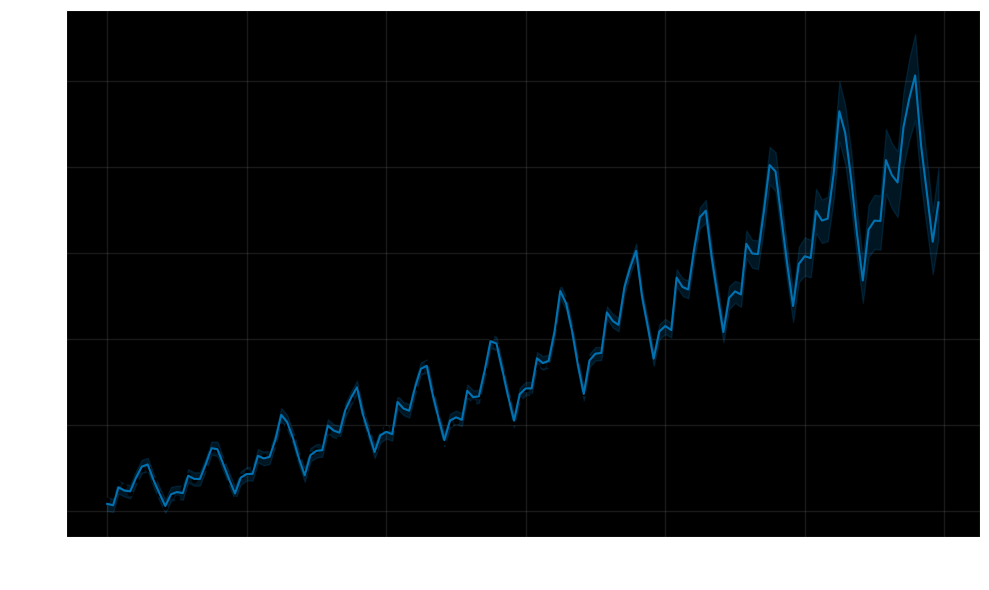

In [144]:
from prophet import Prophet

model = Prophet(seasonality_mode='multiplicative')
model.add_seasonality(name='yearly', period=365.25, fourier_order=10)
model.fit(train)
future = model.make_future_dataframe(periods=12*5, freq='MS')
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])
fig = model.plot(forecast)
plt.show()


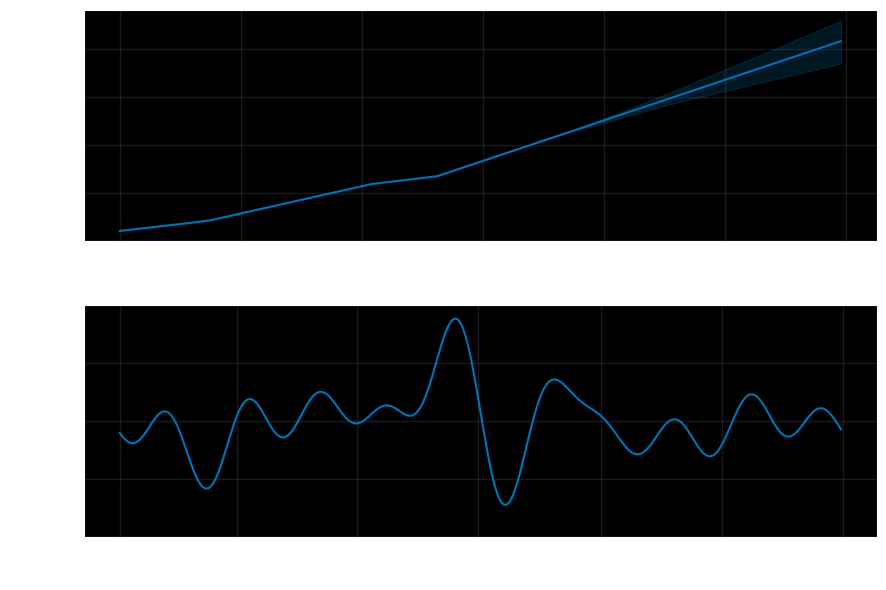

In [145]:
fig2 = model.plot_components(forecast)
plt.show()

In [146]:
forecast[-60:]['yhat']
forecast.rename(columns={'ds':'Month'},inplace=True)
forecast.set_index(keys='Month',inplace=True)

<Axes: xlabel='Month'>

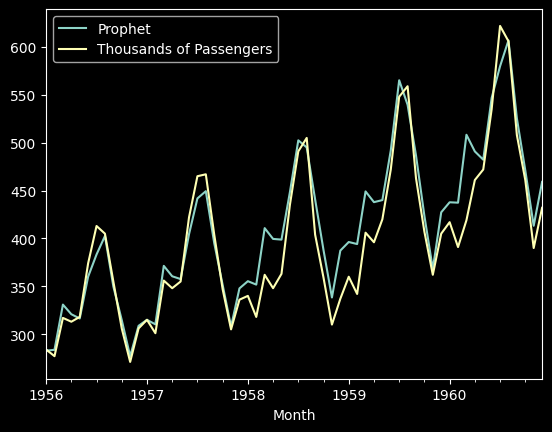

In [147]:
test_df['Prophet'] = forecast[-60:]['yhat']
test_df[['Prophet','Thousands of Passengers']].plot()

In [148]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test_df['Prophet'], test_df['Thousands of Passengers'])
r2 = r2_score(test_df['Prophet'], test_df['Thousands of Passengers'])
print(f"RMSE: {rmse}")
print(f"R2: {r2}")


RMSE: 26.668180229070444
R2: 0.8828948775817005
